# Turbofan Engine Predictive Maintenance (NASA C-MAPSS FD001)

Predicts Remaining Useful Life (RUL) of jet engines from multivariate sensor data with advanced AI.

**Pipeline:** Load data → EDA → Variance pruning → Piecewise RUL target → **Unsupervised Degradation Onset (Isolation Forest)** → Feature engineering → Baseline (Linear Regression) → XGBoost → NASA asymmetric scoring → Hyperparameter tuning → SHAP explainability → Save assets for dashboard → **Extensions:** Sequential LSTM Benchmark & Residual-Calibrated Safe Operating Windows.

In [1]:
!pip install -q xgboost shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import shap
import joblib
import json

np.random.seed(42)

#**Step 1:Load Data**

In [2]:
from google.colab import files
uploaded=files.upload()

Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt


In [ ]:
col_names=['engine_id','cycle','op_setting1','op_setting2','op_setting3'] + \
          [f'sensor_{i}' for i in range(1,22)]

train_df=pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test_df=pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=col_names)
rul_df=pd.read_csv('RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

print(train_df.shape, test_df.shape, rul_df.shape)
train_df.head()

(20631, 26) (13096, 26) (100, 1)


,engine_id,cycle,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


# Step 2: EDA — sensor trends across engine life

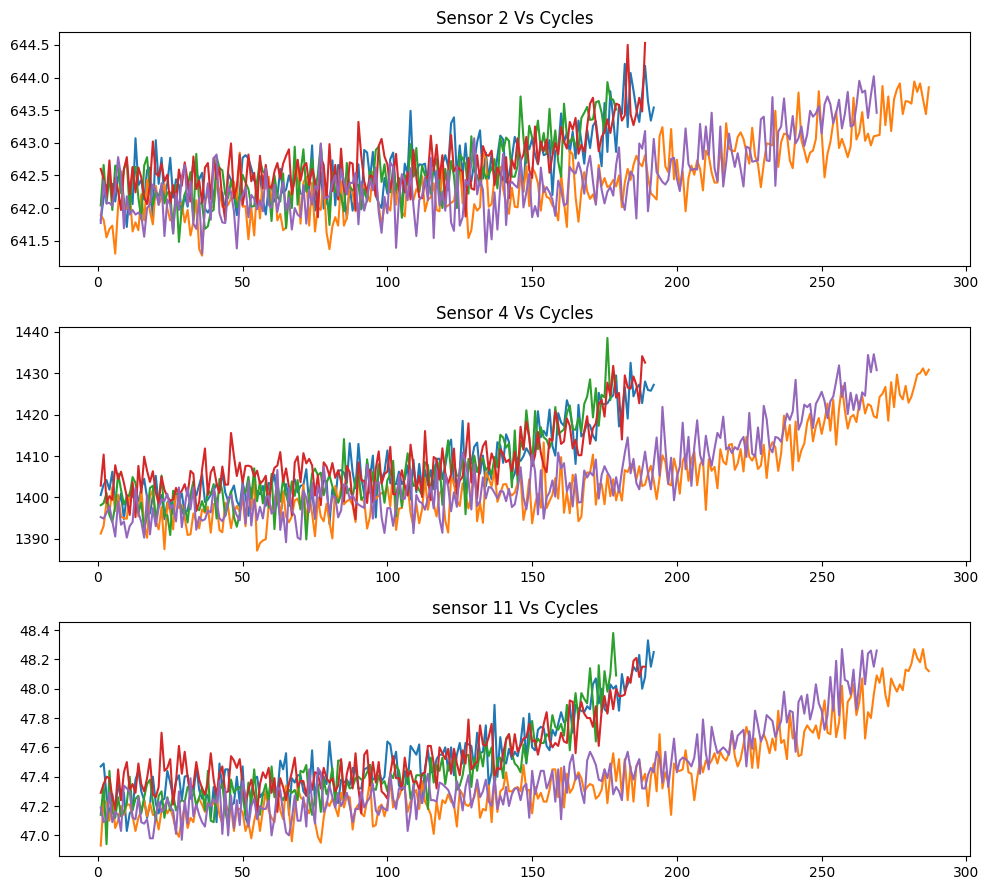

In [ ]:
sample_engines=train_df['engine_id'].unique()[:5]
sensor_cols_all=[c for c in train_df.columns if 'sensor' in c]

fig, axes=plt.subplots(3, 1, figsize=(10,9))
for eng in sample_engines:
  sub=train_df[train_df['engine_id']== eng]
  axes[0].plot(sub['cycle'], sub['sensor_2'], label=f'engine {eng}')
  axes[1].plot(sub['cycle'], sub['sensor_4'], label=f'engine {eng}')
  axes[2].plot(sub['cycle'], sub['sensor_11'], label=f'engine {eng}')
axes[0].set_title('Sensor 2 Vs Cycles');axes[1].set_title('Sensor 4 Vs Cycles');axes[2].set_title('sensor 11 Vs Cycles')

plt.tight_layout()
plt.savefig('eda_sensor_trends.png', dpi=150)
plt.show()

# Step 3: Drop near-constant sensors

In [ ]:
variances=train_df[sensor_cols_all].std()
print(variances.sort_values())

low_var_sensors=variances[variances<0.001].index.tolist()
print('Dropping:', low_var_sensors)

train_df=train_df.drop(columns=low_var_sensors)
test_df=test_df.drop(columns=low_var_sensors)
sensor_cols=[c for c in sensor_cols_all if c not in low_var_sensors]


sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64
Dropping: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


# Step 4: Build the RUL target

In [ ]:
RUL_CAP=125

max_cycles=train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns=['engine_id','max_cycle']
train_df=train_df.merge(max_cycles, on='engine_id')
train_df['RUL']=(train_df['max_cycle'] - train_df['cycle']).clip(upper=RUL_CAP)
train_df=train_df.drop(columns='max_cycle')

train_df[['engine_id','cycle','RUL']].head()

,engine_id,cycle,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


In [ ]:
train_df[['engine_id','cycle','RUL']].tail()

,engine_id,cycle,RUL
20626,100,196,4
20627,100,197,3
20628,100,198,2
20629,100,199,1
20630,100,200,0


# Step 4b: Unsupervised Degradation Onset Detection

Engine #1: Detected unsupervised degradation onset at Cycle 145 (Total Life: 192 cycles)


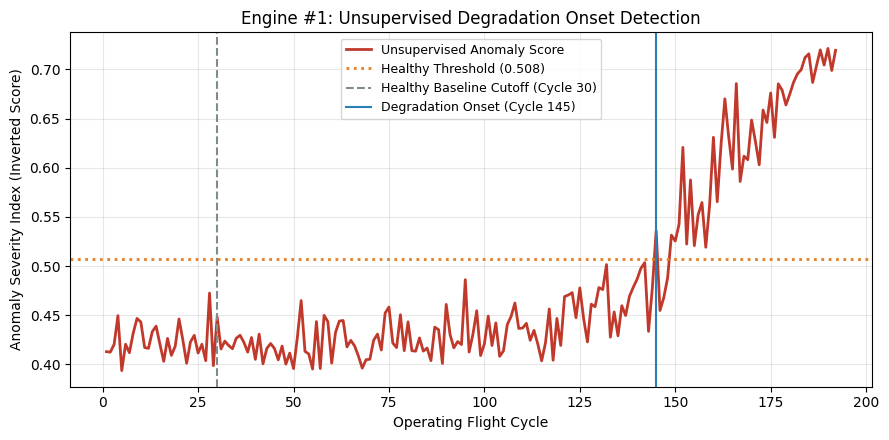

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

HEALTHY_WINDOW=30
healthy_data= train_df[train_df['cycle']<=HEALTHY_WINDOW][sensor_cols]

scaled_unsup = StandardScaler()
X_healthy_scaled=scaled_unsup.fit_transform(healthy_data)

iso_forest=IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_healthy_scaled)

sample_id=1
sample_eng=train_df[train_df['engine_id']==sample_id].sort_values('cycle')
X_sample_scaled=scaled_unsup.transform(sample_eng[sensor_cols])

anomaly_scores = -iso_forest.score_samples(X_sample_scaled)

baseline_threshold = np.percentile(-iso_forest.score_samples(X_healthy_scaled), 95)

onset_cycles = sample_eng['cycle'].values[anomaly_scores > baseline_threshold]
onset_cycle = onset_cycles[0] if len(onset_cycles) > 0 else 'Not detected'
print(f'Engine #{sample_id}: Detected unsupervised degradation onset at Cycle {onset_cycle} (Total Life: {sample_eng["cycle"].max()} cycles)')

plt.figure(figsize=(9, 4.5))
plt.plot(sample_eng['cycle'], anomaly_scores, color='#c0392b', lw=2, label='Unsupervised Anomaly Score')
plt.axhline(y=baseline_threshold, color='#e67e22', linestyle=':', lw=2, label=f'Healthy Threshold ({baseline_threshold:.3f})')
plt.axvline(x=HEALTHY_WINDOW, color='#7f8c8d', linestyle='--', label=f'Healthy Baseline Cutoff (Cycle {HEALTHY_WINDOW})')
if isinstance(onset_cycle, (int, float, np.integer)):
    plt.axvline(x=onset_cycle, color='#2980b9', linestyle='-', lw=1.5, label=f'Degradation Onset (Cycle {onset_cycle})')
plt.title(f'Engine #{sample_id}: Unsupervised Degradation Onset Detection')
plt.xlabel('Operating Flight Cycle')
plt.ylabel('Anomaly Severity Index (Inverted Score)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('unsupervised_anomaly_onset.png', dpi=150)
plt.show()

In [ ]:
iso_artifacts = {
    "scaler": scaled_unsup,
    "iso_forest": iso_forest,
    "threshold": float(baseline_threshold),
    "sensor_cols": sensor_cols
}

joblib.dump(iso_artifacts, "iso_forest_onset_model.pkl")

try:
    from google.colab import files
    files.download("iso_forest_onset_model.pkl")
except Exception:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Step 5: Feature engineering — rolling stats + degradation slope

In [ ]:
def slope(x):
    if len(x) < 2:
        return 0.0
    return linregress(range(len(x)), x)[0]

def add_features(df, sensor_cols, roll_window=5, slope_window=10):
    df = df.copy()
    for col in sensor_cols:
        df[f'{col}_rollmean'] = df.groupby('engine_id')[col].transform(
            lambda x: x.rolling(roll_window, min_periods=1).mean())
        df[f'{col}_rollstd'] = df.groupby('engine_id')[col].transform(
            lambda x: x.rolling(roll_window, min_periods=1).std().fillna(0))
        df[f'{col}_slope'] = df.groupby('engine_id')[col].transform(
            lambda x: x.rolling(slope_window, min_periods=2).apply(slope, raw=True).fillna(0))
    return df

train_df = add_features(train_df, sensor_cols)
test_df = add_features(test_df, sensor_cols)

train_df.head()

,engine_id,cycle,op_setting1,op_setting2,op_setting3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_15_slope,sensor_17_rollmean,sensor_17_rollstd,sensor_17_slope,sensor_20_rollmean,sensor_20_rollstd,sensor_20_slope,sensor_21_rollmean,sensor_21_rollstd,sensor_21_slope
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,0.00000,392.000000,0.000000,0.0,39.060000,0.000000,0.000,23.419000,0.000000,0.00000
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,0.01230,392.000000,0.000000,0.0,39.030000,0.042426,-0.060,23.421300,0.003253,0.00460
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,-0.00085,391.333333,1.154701,-1.0,39.003333,0.055076,-0.055,23.395600,0.044573,-0.03740
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,-0.01679,391.500000,1.000000,-0.2,38.972500,0.076322,-0.059,23.390175,0.037977,-0.02147
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,-0.00438,391.800000,1.095445,0.2,38.958000,0.073621,-0.044,23.393020,0.033498,-0.00789


# Step 6: Prepare the test set

In [ ]:
test_last = test_df.groupby('engine_id').last().reset_index()
rul_df['engine_id'] = rul_df.index + 1
test_last = test_last.merge(rul_df, on='engine_id')
test_last['RUL'] = test_last['RUL'].clip(upper=RUL_CAP)

test_last.head()

,engine_id,cycle,op_setting1,op_setting2,op_setting3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_17_rollmean,sensor_17_rollstd,sensor_17_slope,sensor_20_rollmean,sensor_20_rollstd,sensor_20_slope,sensor_21_rollmean,sensor_21_rollstd,sensor_21_slope,RUL
0,1,31,-0.0006,0.0004,100.0,642.58,1581.22,1398.91,21.61,554.42,...,392.0,0.707107,-0.072727,38.924,0.124016,-0.006848,23.37350,0.025037,0.001208,112
1,2,49,0.0018,-0.0001,100.0,642.55,1586.59,1410.83,21.61,553.52,...,392.2,1.095445,-0.145455,38.902,0.069785,0.014727,23.27434,0.027820,-0.006850,98
2,3,126,-0.0016,0.0004,100.0,642.88,1589.75,1418.89,21.61,552.59,...,394.2,0.836660,0.066667,38.686,0.143631,-0.016061,23.24412,0.018966,0.002564,69
3,4,106,0.0012,0.0004,100.0,642.78,1594.53,1406.88,21.61,552.64,...,393.6,1.341641,0.109091,38.758,0.126372,-0.021515,23.25156,0.021106,-0.004164,82
4,5,98,-0.0013,-0.0004,100.0,642.27,1589.94,1419.36,21.61,553.29,...,393.4,0.547723,0.006061,38.810,0.091924,0.006667,23.29114,0.101100,0.017412,91


# Step 7: Baseline — Linear Regression

In [ ]:
feature_cols = [c for c in train_df.columns if c not in ['engine_id', 'cycle', 'RUL']]

X_train, y_train = train_df[feature_cols], train_df['RUL']
X_test, y_test = test_last[feature_cols], test_last['RUL']

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

print('Baseline Linear Regression RMSE:', np.sqrt(mean_squared_error(y_test, lr_preds)))

Baseline Linear Regression RMSE: 20.517372170152193


# Step 8: Main model — XGBoost with GroupKFold cross-validation

In [ ]:
gkf = GroupKFold(n_splits=5)
groups = train_df['engine_id']

cv_rmses = []
for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    model = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8, random_state=42)
    model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    preds = model.predict(X_train.iloc[val_idx])
    rmse = np.sqrt(mean_squared_error(y_train.iloc[val_idx], preds))
    cv_rmses.append(rmse)
    print(f'Fold {fold}: RMSE = {rmse:.3f}')

print('Mean CV RMSE:', np.mean(cv_rmses))

Fold 0: RMSE = 18.222
Fold 1: RMSE = 18.327
Fold 2: RMSE = 15.787
Fold 3: RMSE = 19.438
Fold 4: RMSE = 15.761
Mean CV RMSE: 17.506906536113412


# Step 9: NASA asymmetric scoring function

In [ ]:
def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    score = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return np.sum(score)

def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    score = nasa_score(y_true, y_pred)
    print(f'{label} -> RMSE: {rmse:.3f} | NASA score: {score:.1f}')
    return rmse, score

evaluate(y_test, lr_preds, 'Baseline (Linear Regression, test set)')

Baseline (Linear Regression, test set) -> RMSE: 20.517 | NASA score: 1104.7


(np.float64(20.517372170152193), np.float64(1104.679148763341))

# Step 10: Hyperparameter tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=GroupKFold(n_splits=5).split(X_train, y_train, groups),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


# Step 11: Final evaluation on the held-out test set

In [ ]:
final_preds = best_model.predict(X_test)

rmse_final, score_final = evaluate(y_test, final_preds, 'Tuned XGBoost (test set)')
evaluate(y_test, lr_preds, 'Baseline for comparison (test set)')

results_table = pd.DataFrame({
    'Model': ['Linear Regression (baseline)', 'XGBoost (tuned)'],
    'RMSE': [np.sqrt(mean_squared_error(y_test, lr_preds)), rmse_final],
    'NASA Score': [nasa_score(y_test, lr_preds), score_final],
})
results_table.to_csv('results_table.csv', index=False)
results_table

Tuned XGBoost (test set) -> RMSE: 16.978 | NASA score: 820.1
Baseline for comparison (test set) -> RMSE: 20.517 | NASA score: 1104.7


,Model,RMSE,NASA Score
0,Linear Regression (baseline),20.517372,1104.679149
1,XGBoost (tuned),16.978229,820.119437


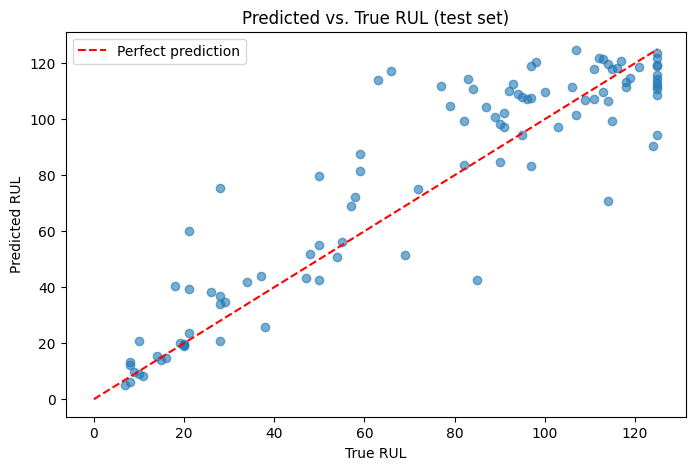

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, final_preds, alpha=0.6)
plt.plot([0, RUL_CAP], [0, RUL_CAP], 'r--', label='Perfect prediction')
plt.xlabel('True RUL'); plt.ylabel('Predicted RUL')
plt.title('Predicted vs. True RUL (test set)')
plt.legend()
plt.savefig('pred_vs_true.png', dpi=150)
plt.show()

# Step 12: SHAP explainability

/tmp/ipykernel_11159/1140087959.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


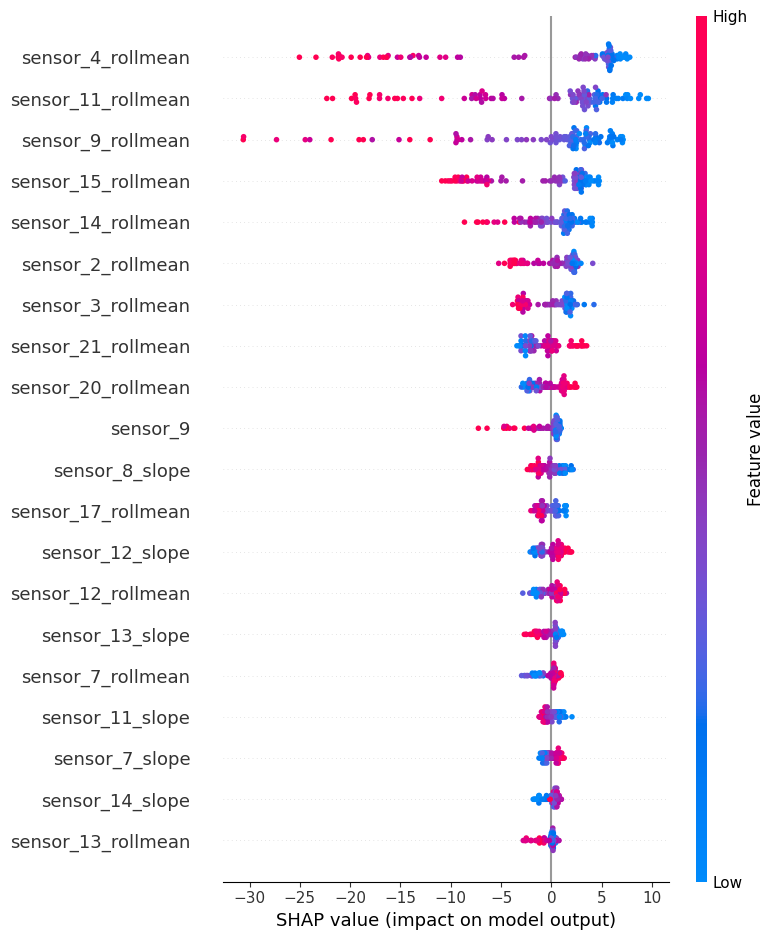

In [ ]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

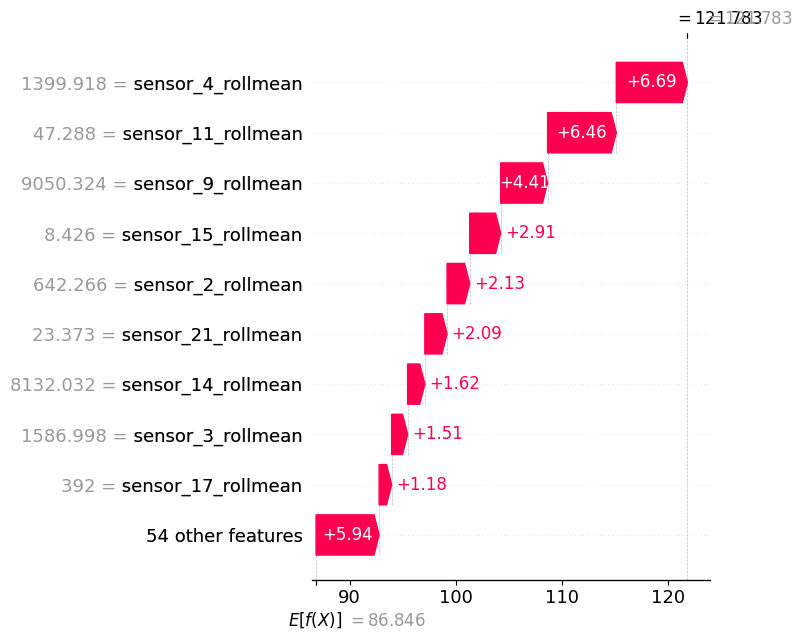

Engine 1.0: true RUL = 112, predicted RUL = 121.8


In [ ]:
plt.close('all')

idx = 0

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[idx],
    feature_names=X_test.columns.tolist()
)

shap.plots.waterfall(explanation, max_display=10, show=False)
plt.tight_layout()
plt.savefig('shap_force_example.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Engine {test_last.iloc[idx]['engine_id']}: true RUL = {y_test.iloc[idx]}, predicted RUL = {final_preds[idx]:.1f}")

# Step 13: Save everything needed for the dashboard

In [ ]:
joblib.dump(best_model, 'model.pkl')

with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

with open('sensor_cols.json', 'w') as f:
    json.dump(sensor_cols, f)

dashboard_cols = ['engine_id', 'cycle'] + sensor_cols + feature_cols + ['RUL']
dashboard_cols = list(dict.fromkeys(dashboard_cols))
train_df[dashboard_cols].to_csv('dashboard_data.csv', index=False)

files.download('model.pkl')
files.download('feature_cols.json')
files.download('sensor_cols.json')
files.download('dashboard_data.csv')
files.download('eda_sensor_trends.png')
files.download('pred_vs_true.png')
files.download('shap_summary.png')
files.download('shap_force_example.png')
files.download('unsupervised_anomaly_onset.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Extension: LSTM Sequence Model Comparison

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)

SEQ_LEN = 30

# Step 14: Scale raw sensors and build sliding-window sequences

In [ ]:
scaler = StandardScaler()
scaler.fit(train_df[sensor_cols])

train_df_scaled = train_df.copy()
train_df_scaled[sensor_cols] = scaler.transform(train_df[sensor_cols])

test_df_scaled = test_df.copy()
test_df_scaled[sensor_cols] = scaler.transform(test_df[sensor_cols])


def build_train_sequences(df, sensor_cols, seq_len):
    X_seqs, y_seqs = [], []
    for eng_id, group in df.groupby('engine_id'):
        group = group.sort_values('cycle')
        data = group[sensor_cols].values
        ruls = group['RUL'].values
        n = len(group)
        for end_idx in range(n):
            start_idx = max(0, end_idx - seq_len + 1)
            seq = data[start_idx:end_idx + 1]
            if len(seq) < seq_len:
                pad = np.zeros((seq_len - len(seq), len(sensor_cols)))
                seq = np.vstack([pad, seq])
            X_seqs.append(seq)
            y_seqs.append(ruls[end_idx])
    return np.array(X_seqs), np.array(y_seqs)


def build_test_sequences(df, sensor_cols, seq_len):
    X_seqs, eng_ids = [], []
    for eng_id, group in df.groupby('engine_id'):
        group = group.sort_values('cycle')
        data = group[sensor_cols].values
        seq = data[-seq_len:]
        if len(seq) < seq_len:
            pad = np.zeros((seq_len - len(seq), len(sensor_cols)))
            seq = np.vstack([pad, seq])
        X_seqs.append(seq)
        eng_ids.append(eng_id)
    return np.array(X_seqs), eng_ids


X_train_seq, y_train_seq = build_train_sequences(train_df_scaled, sensor_cols, SEQ_LEN)
X_test_seq, test_eng_ids = build_test_sequences(test_df_scaled, sensor_cols, SEQ_LEN)
y_test_seq = test_last.set_index('engine_id').loc[test_eng_ids]['RUL'].values

print('Train sequences:', X_train_seq.shape)
print('Test sequences:', X_test_seq.shape)

Train sequences: (20631, 30, 15)
Test sequences: (100, 30, 15)


# Step 15: Build and train the LSTM

In [ ]:
lstm_model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(sensor_cols))),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1),
])

lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,441 (130.63 KB)

 Trainable params: 33,441 (130.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - loss: 7595.5981 - val_loss: 6648.1733
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - loss: 4990.4883 - val_loss: 4200.5601
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step - loss: 2843.5117 - val_loss: 2107.3540
Epoch 4/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 1295.9922 - val_loss: 840.5135
Epoch 5/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - loss: 556.2903 - val_loss: 374.3376
Epoch 6/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 313.6733 - val_loss: 266.5269
Epoch 7/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - loss: 232.8887 - val_loss: 251.3236
Epoch 8/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 206.3665 - val_loss: 239.8914
Epoch 9/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - loss: 192.2178 - val_loss: 241.3962
Epoch 10/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 117ms/step - loss: 185.1532 - val_loss: 229.8738
Epoch 11/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 179.3405 - val_loss: 213.8972
Epo

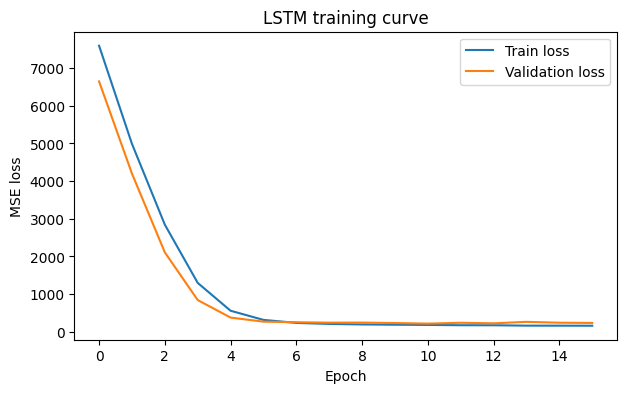

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.title('LSTM training curve')
plt.legend()
plt.savefig('lstm_training_curve.png', dpi=150)
plt.show()

# Step 16: Evaluate LSTM vs. tuned XGBoost

In [ ]:
lstm_preds = lstm_model.predict(X_test_seq).flatten()

rmse_lstm, score_lstm = evaluate(y_test_seq, lstm_preds, 'LSTM (test set)')
evaluate(y_test, final_preds, 'Tuned XGBoost for comparison (test set)')
evaluate(y_test, lr_preds, 'Baseline Linear Regression for comparison (test set)')


results_table = pd.DataFrame({
    'Model': ['Linear Regression (baseline)', 'XGBoost (tuned)', 'LSTM (raw sequences)'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        rmse_final,
        rmse_lstm,
    ],
    'NASA Score': [
        nasa_score(y_test, lr_preds),
        score_final,
        score_lstm,
    ],
})
results_table.to_csv('results_table.csv', index=False)
results_table

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
LSTM (test set) -> RMSE: 13.920 | NASA score: 356.6
Tuned XGBoost for comparison (test set) -> RMSE: 16.978 | NASA score: 820.1
Baseline Linear Regression for comparison (test set) -> RMSE: 20.517 | NASA score: 1104.7


,Model,RMSE,NASA Score
0,Linear Regression (baseline),20.517372,1104.679149
1,XGBoost (tuned),16.978229,820.119437
2,LSTM (raw sequences),13.919751,356.634705


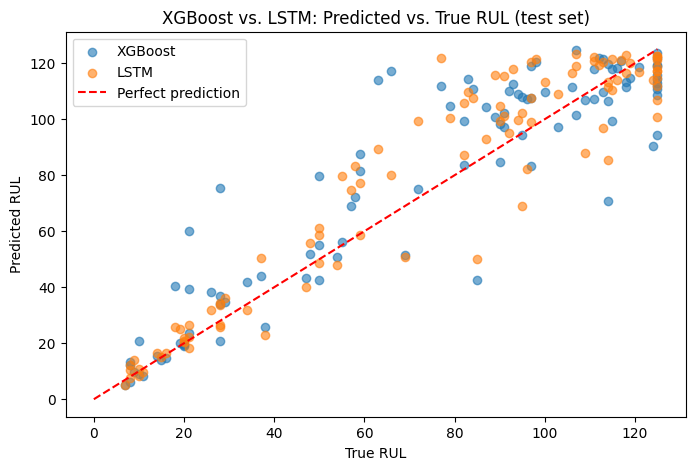

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, final_preds, alpha=0.6, label='XGBoost')
plt.scatter(y_test_seq, lstm_preds, alpha=0.6, label='LSTM')
plt.plot([0, RUL_CAP], [0, RUL_CAP], 'r--', label='Perfect prediction')
plt.xlabel('True RUL'); plt.ylabel('Predicted RUL')
plt.title('XGBoost vs. LSTM: Predicted vs. True RUL (test set)')
plt.legend()
plt.savefig('xgb_vs_lstm.png', dpi=150)
plt.show()

In [ ]:
files.download('results_table.csv')
files.download('lstm_training_curve.png')
files.download('xgb_vs_lstm.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Extension: Safe Operating Window (Conservative RUL Estimate)

In [ ]:
CONFIDENCE = 0.95

oof_preds = np.zeros(len(X_train))

for tr_idx, val_idx in GroupKFold(n_splits=5).split(X_train, y_train, groups):
    fold_model = XGBRegressor(**search.best_params_, random_state=42)
    fold_model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
    oof_preds[val_idx] = fold_model.predict(X_train.iloc[val_idx])

residuals = oof_preds - y_train.values

safety_margin = max(np.percentile(residuals, CONFIDENCE * 100), 0)
print(f'Safety margin at {CONFIDENCE*100:.0f}% confidence: {safety_margin:.1f} cycles')

Safety margin at 95% confidence: 35.3 cycles


In [ ]:
safe_floor_test = np.clip(final_preds - safety_margin, 0, None)
coverage = (y_test.values >= safe_floor_test).mean()
print(f'Coverage check: {coverage*100:.1f}% of test engines had true RUL >= predicted safe floor '
      f'(target: {CONFIDENCE*100:.0f}%)')

Coverage check: 96.0% of test engines had true RUL >= predicted safe floor (target: 95%)


In [ ]:
with open('safety_margin.json', 'w') as f:
    json.dump({'margin_cycles': float(safety_margin), 'confidence_level': CONFIDENCE}, f)

files.download('safety_margin.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>